 # Working With Boston AirBnB Data 

In this project for my DataScience Nanodegree Program from Udacity, I decided to do an analysis on Boston AirBnB data 
from https://www.kaggle.com/airbnb/boston. I have three main questions that I want to find answers to and they are:













 1) Do AirBnb properties near Boston Logan International Airport tend to get higher ratings on location?
 
 2)  What does the difference in prices look like between the properties near the airport compared to those farther than  airport? (For this analysis, I will be focusing on only one bedroom rentals)

 3) Compare the overall review

# Process

In order to compare the ratings of location between properties near and farther than airport, I will be using 'longitude' and 'latitude' for each property and compute the distance between that property to that of Boston Logan International Airport which is 42.366978(latitude) and 71.022362(longitude) 
Credit: https://www.latlong.net/place/logan-international-airport-bos-boston-ma-usa-1815.html 

In order to compute the distance between two points , I am using haversine formula with errors typically upto 0.3%

Haversine formula:	a = sin²(Δφ/2) + cos φ1 ⋅ cos φ2 ⋅ sin²(Δλ/2)
                    c = 2 ⋅ atan2( √a, √(1−a) )
                    d = R ⋅ c
                    where	φ is latitude, λ is longitude, R is earth’s radius (mean radius = 6,371km);
                    note that angles need to be in radians to pass to trig functions! This gives the distance in km
Credit:https://www.movable-type.co.uk/scripts/latlong.html


In [170]:
# Basic Import and Setup

import numpy as np
from math import *
import pandas as pd
import re 
from re import sub
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
%matplotlib inline

listings_df = pd.read_csv('./Boston Data/listings.csv')
reviews_df = pd.read_csv('./Boston Data/reviews.csv')
listings_df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,20160906204935,2016-09-07,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47
3,1436513,https://www.airbnb.com/rooms/1436513,20160906204935,2016-09-07,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,10.0,f,NaN,NaN,f,moderate,f,f,1,1.00
4,7651065,https://www.airbnb.com/rooms/7651065,20160906204935,2016-09-07,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,10.0,f,NaN,NaN,f,flexible,f,f,1,2.25


In [171]:
# Shape of our dataset
# 3585 rows and 95 columns
listings_df.shape

(3585, 95)

In [172]:
listings_df.shape

(3585, 95)

# Question 1

Do AirBnb properties near Boston Logan International Airport tend to get higher ratings on location?  

      Approach that I took:
        1) Create a new dataframe with columns['id','longitude','latitude','review_scores_location']
        2) Create a function to calculate distance between an AirBnb property and the airport
        3) Create a new column 'distance' in new dataframe
        4) Create a function that adds computed distance in 'distance' column
        5) Replace all missing values in 'review_scores_location' with a mean
        6) Create a dictionary object to hold distances as in '0-4' as keys and count of rating 10 on location
           as values.
        7) Create a BarChart of distance vs Count

In [173]:

# Create a dataframe with only the columns we need for the calculation

new_df = listings_df[['id','latitude','longitude','review_scores_location']]
# Check if any of the values in longitude and latitude is missing
sum(new_df['longitude'].isnull()),sum(new_df['latitude'].isnull())


(0, 0)

In [174]:
# Check for missing values in 'review_scores_location'
sum(new_df['review_scores_location'].isnull())

822

In [175]:
new_df.head()

,id,latitude,longitude,review_scores_location
0,12147973,42.282619,-71.133068,NaN
1,3075044,42.286241,-71.134374,9.0
2,6976,42.292438,-71.135765,9.0
3,1436513,42.281106,-71.121021,10.0
4,7651065,42.284512,-71.136258,9.0


In [176]:
def calculate_distance(p1,p2):
    """
        Function that takes two tuples of latitude and longitude and outputs the distance in km
        
        Input: Two Tuple objects of latitude and longitude
        Output: Distance value in km
    """
    R = 6373.0
    lat1 = radians(p1[0])
    lon1 = radians(p1[1])
    lat2 = radians(p2[0])
    lon2 = radians(p2[1])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    
    return distance

In [177]:
# Data Frame after adding a distance column
new_df



,id,latitude,longitude,review_scores_location
0,12147973,42.282619,-71.133068,NaN
1,3075044,42.286241,-71.134374,9.0
2,6976,42.292438,-71.135765,9.0
3,1436513,42.281106,-71.121021,10.0
4,7651065,42.284512,-71.136258,9.0
...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.0
3581,14844274,42.347503,-71.118336,NaN
3582,14585486,42.371771,-71.071300,NaN
3583,14603878,42.385226,-71.080923,8.0


In [178]:
def add_distance_column(df):
    """
        Function that adds computed values(distance of a property from airport) in 'distance' column
        
        Input: Takes in a dataframe object as input
        Output: Returns a new dataframe object with new 'distance' column
    """
    df['distance'] = 0
    for i in range(len(df)):
        p1 = (df.loc[i,'latitude'] , df.loc[i,'longitude'])
        p2 = (42.366978,-71.022362)
        df.loc[i,'distance'] = calculate_distance(p1,p2) / 1.609344
    return df

# Apply the function on new_df
new_df = add_distance_column(new_df)



<ipython-input-178-7acb7e60985f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = 0
/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [179]:
new_df

,id,latitude,longitude,review_scores_location,distance
0,12147973,42.282619,-71.133068,NaN,8.123816
1,3075044,42.286241,-71.134374,9.0,7.993593
2,6976,42.292438,-71.135765,9.0,7.753480
3,1436513,42.281106,-71.121021,10.0,7.787248
4,7651065,42.284512,-71.136258,9.0,8.146005
...,...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.0,3.282376
3581,14844274,42.347503,-71.118336,NaN,5.083112
3582,14585486,42.371771,-71.071300,NaN,2.520788
3583,14603878,42.385226,-71.080923,8.0,3.245099


In [180]:
# Check for the correlation and as we can see that there is a negative correlation between 'review_scores_location' and 'distance'
corrM = new_df.corr()
corrM['review_scores_location'].sort_values(ascending=False)

review_scores_location    1.000000
latitude                  0.229395
id                        0.044997
longitude                 0.038539
distance                 -0.186709
Name: review_scores_location, dtype: float64

In [181]:
# Counting the number of missing values in 'review_scores_location'
sum(new_df['review_scores_location'].isnull())

822

In [182]:
#Filling the missing values with mean in 'review_scores_location' column
new_df['review_scores_location'].fillna(value=new_df['review_scores_location'].mean(),inplace=True)

/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [183]:
new_df

,id,latitude,longitude,review_scores_location,distance
0,12147973,42.282619,-71.133068,9.414043,8.123816
1,3075044,42.286241,-71.134374,9.000000,7.993593
2,6976,42.292438,-71.135765,9.000000,7.753480
3,1436513,42.281106,-71.121021,10.000000,7.787248
4,7651065,42.284512,-71.136258,9.000000,8.146005
...,...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.000000,3.282376
3581,14844274,42.347503,-71.118336,9.414043,5.083112
3582,14585486,42.371771,-71.071300,9.414043,2.520788
3583,14603878,42.385226,-71.080923,8.000000,3.245099


<AxesSubplot:xlabel='distance', ylabel='review_scores_location'>

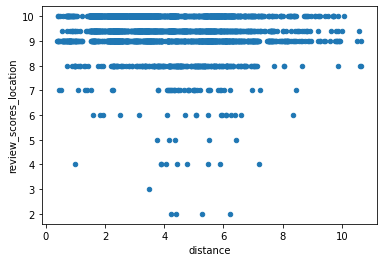

In [184]:
new_df.plot(kind="scatter",y="review_scores_location",x="distance")

In [185]:
def count_rating_10(df):
    """
        Function to count the number of ratings with score 10 on location
        
        Input: Takes in a dataframe object
        Ouptue: Returns a dictionary object with distances e.g. '0-4' as key and count of rating 10 as values
    
    """
    count_10 = {'0-4':0,'4-8':0,'8-12':0}
    for i in range(len(df)):
        rating = df.loc[i,'review_scores_location']
        d = df.loc[i,'distance']
        if rating == 10:
            if d > 0 and d < 4:
                count_10['0-4'] += 1
            elif d > 4 and d < 8:
                count_10['4-8'] += 1
            else:
                count_10['8-12'] += 1
    return count_10
    

In [186]:
# Assign the output to count_10
count_10 = count_rating_10(new_df)   

In [187]:
count_10

{'0-4': 1130, '4-8': 458, '8-12': 32}

In [188]:
def create_key_and_val_lists(d):
    """
        Fucntion that takes in a dictionary object and returns a tuple of two lists of keys and values
        
        Input: Dictionary Object
        Output: Tuple of two lists with keys holding keys and val holding values of a dictionary
    """
    keys = []
    val = []
    for key,value in d.items():
        keys.append(key)
        val.append(value)
    return (keys,val)


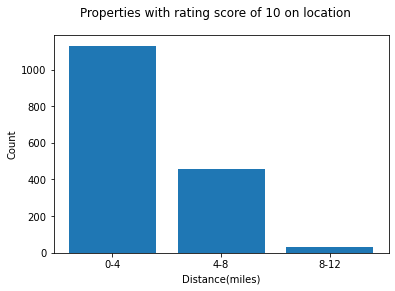

In [190]:
def plot_bar_chart(keys,values):
    """
        Function that creates a bar chart for distance vs count.
        
        Input: Takes in two lists (keys: horizontal axis  and values: vertical axis)
        Output: Prints the barchart on the screen and saves the figure in local machine
    """
    plt.bar(keys,values, align='center')
    plt.xticks(keys)
    plt.suptitle('Properties with rating score of 10 on location')
    plt.xlabel("Distance(miles)")
    plt.ylabel("Count")
    plt.savefig("Rating-10-count", format='png')
    plt.show()
    
k, v = create_key_and_val_lists(count_10)
plot_bar_chart(k,v)


Findings   :   More properties near the distance of 0-4 miles have ratings of 10 on location compared to properties farther than 4 miles and so.



# Question 2


In [162]:
# Only Select properties with one bedroom and assign it to a new dataframe
prices_comp_df = listings_df[['id','bedrooms','latitude','longitude','price']]

In [163]:
# Cleaning the price column
def clean_price(price):
    """
        Function that converts a string with '$' prefix to an a float after removing $
        
        Input: String
        Output: Float
    """
    try:
        return float(sub(r'[^\d.]','',price))
    except:
        return float(price)
prices_comp_df['price'] = prices_comp_df['price'].map(clean_price)

<ipython-input-163-6a9f3b4198fd>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices_comp_df['price'] = prices_comp_df['price'].map(clean_price)


In [164]:
prices_comp_df

,id,bedrooms,latitude,longitude,price
0,12147973,2.0,42.282619,-71.133068,250.0
1,3075044,1.0,42.286241,-71.134374,65.0
2,6976,1.0,42.292438,-71.135765,65.0
3,1436513,1.0,42.281106,-71.121021,75.0
4,7651065,1.0,42.284512,-71.136258,79.0
...,...,...,...,...,...
3580,8373729,1.0,42.380968,-71.083795,69.0
3581,14844274,1.0,42.347503,-71.118336,150.0
3582,14585486,1.0,42.371771,-71.071300,198.0
3583,14603878,1.0,42.385226,-71.080923,65.0


In [165]:
# Add distance column
prices_comp_df = add_distance_column(prices_comp_df)

<ipython-input-161-7acb7e60985f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = 0
/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [166]:
prices_comp_df.head()

,id,bedrooms,latitude,longitude,price,distance
0,12147973,2.0,42.282619,-71.133068,250.0,8.123816
1,3075044,1.0,42.286241,-71.134374,65.0,7.993593
2,6976,1.0,42.292438,-71.135765,65.0,7.753480
3,1436513,1.0,42.281106,-71.121021,75.0,7.787248
4,7651065,1.0,42.284512,-71.136258,79.0,8.146005


In [167]:
one_bedroom_df = prices_comp_df[prices_comp_df['bedrooms']==1]


In [168]:
one_bedroom_df

,id,bedrooms,latitude,longitude,price,distance
1,3075044,1.0,42.286241,-71.134374,65.0,7.993593
2,6976,1.0,42.292438,-71.135765,65.0,7.753480
3,1436513,1.0,42.281106,-71.121021,75.0,7.787248
4,7651065,1.0,42.284512,-71.136258,79.0,8.146005
5,12386020,1.0,42.291690,-71.131893,75.0,7.641882
...,...,...,...,...,...,...
3580,8373729,1.0,42.380968,-71.083795,69.0,3.282376
3581,14844274,1.0,42.347503,-71.118336,150.0,5.083112
3582,14585486,1.0,42.371771,-71.071300,198.0,2.520788
3583,14603878,1.0,42.385226,-71.080923,65.0,3.245099


In [193]:
sum(one_bedroom_df['bedrooms'].isnull())

0

[(0.0, 800.0)]

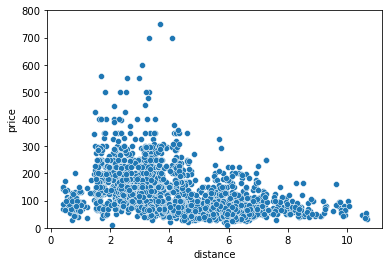

In [208]:
# Using Seaborn to create a scatterplot
scatter_plot = sns.scatterplot(data=one_bedroom_df,x='distance',y='price')
